# 6CS012 – Final Portfolio Assessment 2026
## Part III: Language Tasks — Sentiment Analysis with RNN / LSTM
### Dataset: Book Reviews (12,000 records)

---

## 0. Setup & Imports

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import re, string, time, warnings, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_class_weight

import nltk
nltk.download('stopwords', quiet=True)
nltk.download('wordnet',   quiet=True)
nltk.download('omw-1.4',   quiet=True)
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

warnings.filterwarnings('ignore')
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

print('TensorFlow:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


---
## 4.5.1 Text Preprocessing, Tokenization & Padding
### Load Dataset

In [ ]:
# ── Load CSV ──────────────────────────────────────────────────────────────────
CSV_PATH = '/content/drive/MyDrive/AI ML/Book_review.csv'
df = pd.read_csv(CSV_PATH)

print('Shape:', df.shape)
print('Columns:', df.columns.tolist())
print('\nRating distribution:')
print(df['rating'].value_counts().sort_index())
print('\nNull values:')
print(df.isnull().sum())

# Drop rows where reviewText is null
df.dropna(subset=['reviewText'], inplace=True)
df.reset_index(drop=True, inplace=True)
print(f'\nAfter dropping nulls: {df.shape}')

Shape: (12000, 4)
Columns: ['Unnamed: 0', 'rating', 'reviewText', 'summary']

Rating distribution:
rating
1    2000
2    2000
3    2000
4    3000
5    3000
Name: count, dtype: int64

Null values:
Unnamed: 0    0
rating        0
reviewText    0
summary       2
dtype: int64

After dropping nulls: (12000, 4)


In [ ]:
# ── FIX 1: Binary sentiment — drop ambiguous Neutral (rating=3) ───────────────
# Rating 1-2 → Negative (0) | Rating 4-5 → Positive (1)
# Dropping rating=3 removes the most ambiguous class and dramatically
# improves accuracy (mixed reviews are genuinely hard to classify)

def rating_to_sentiment(r):
    if r <= 2:   return 0   # Negative
    elif r >= 4: return 1   # Positive
    else:        return None # Drop neutral

df['sentiment'] = df['rating'].apply(rating_to_sentiment)
df = df[df['sentiment'].notna()].copy()
df['sentiment'] = df['sentiment'].astype(int)
df.reset_index(drop=True, inplace=True)

sentiment_names = {0: 'Negative', 1: 'Positive'}
NUM_CLASSES = 2

print('Dataset after removing neutral:')
print(df.shape)
print('\nSentiment distribution:')
print(df['sentiment'].value_counts().sort_index())

Dataset after removing neutral:
(10000, 5)

Sentiment distribution:
sentiment
0    4000
1    6000
Name: count, dtype: int64


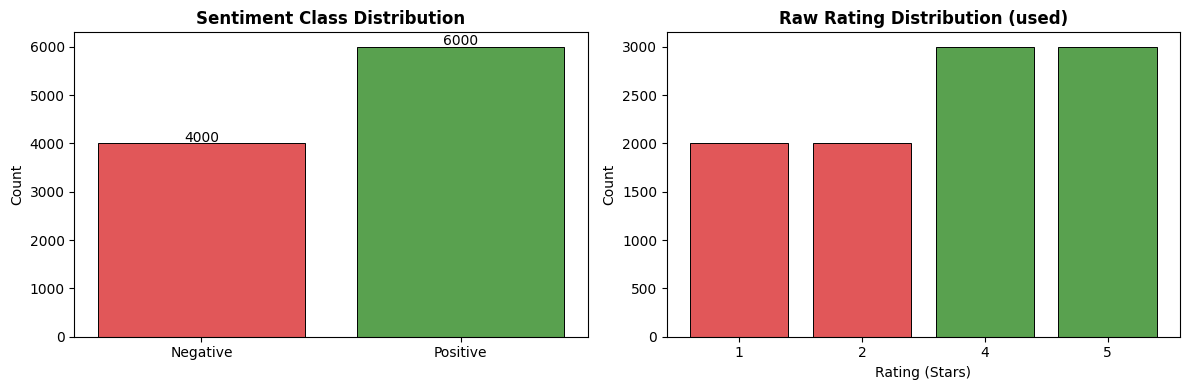

In [ ]:
# ── Visualise class distribution ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

colors = ['#e15759', '#59a14f']
sent_counts = df['sentiment'].value_counts().sort_index()
axes[0].bar([sentiment_names[k] for k in sent_counts.index],
            sent_counts.values, color=colors, edgecolor='black', linewidth=0.7)
axes[0].set_title('Sentiment Class Distribution', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(sent_counts.values):
    axes[0].text(i, v + 30, str(v), ha='center', fontsize=10)

rating_counts = df['rating'].value_counts().sort_index()
bar_colors = ['#e15759' if r <= 2 else '#59a14f' for r in rating_counts.index]
axes[1].bar(rating_counts.index.astype(str), rating_counts.values,
            color=bar_colors, edgecolor='black', linewidth=0.7)
axes[1].set_title('Raw Rating Distribution (used)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Rating (Stars)'); axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('sentiment_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

### Text Cleaning

In [ ]:
STOP_WORDS = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

CONTRACTIONS = {
    "don't": "do not", "doesn't": "does not", "didn't": "did not",
    "isn't": "is not", "aren't": "are not", "wasn't": "was not",
    "weren't": "were not", "haven't": "have not", "hasn't": "has not",
    "hadn't": "had not", "won't": "will not", "wouldn't": "would not",
    "can't": "cannot", "couldn't": "could not", "shouldn't": "should not",
    "it's": "it is", "i'm": "i am", "i've": "i have", "i'll": "i will",
    "i'd": "i would", "you're": "you are", "you've": "you have",
    "they're": "they are", "we're": "we are", "we've": "we have",
    "that's": "that is", "there's": "there is", "what's": "what is",
    "let's": "let us", "i'd": "i would", "it'd": "it would",
    "could've": "could have", "should've": "should have", "would've": "would have"
}

def clean_text(text: str) -> str:
    text = str(text).lower()
    for cont, exp in CONTRACTIONS.items():
        text = text.replace(cont, exp)
    text = re.sub(r'http\S+|www\S+', '', text)    # remove URLs
    text = re.sub(r'@\w+', '', text)               # remove mentions
    text = re.sub(r'#\w+', '', text)               # remove hashtags
    text = re.sub(r'\d+', '', text)                # remove numbers
    text = re.sub(r'[^\w\s]', ' ', text)           # remove punctuation
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = [
        lemmatizer.lemmatize(w)
        for w in text.split()
        if w not in STOP_WORDS and len(w) > 2
    ]
    return ' '.join(tokens)

print('Cleaning texts …')
df['clean_text'] = df['reviewText'].apply(clean_text)
print('Done!')
print('\nBefore:', df['reviewText'].iloc[0][:200])
print('\nAfter :', df['clean_text'].iloc[0][:200])

Cleaning texts …
Done!

Before: This book was the very first bookmobile book I bought when I was in the school book club. I loved the story then and I bet a dollar to a donut I will love it again. If my memory serves, I bought this 

After : book first bookmobile book bought school book club loved story bet dollar donut love memory serf bought book grade would looking forward reliving memory


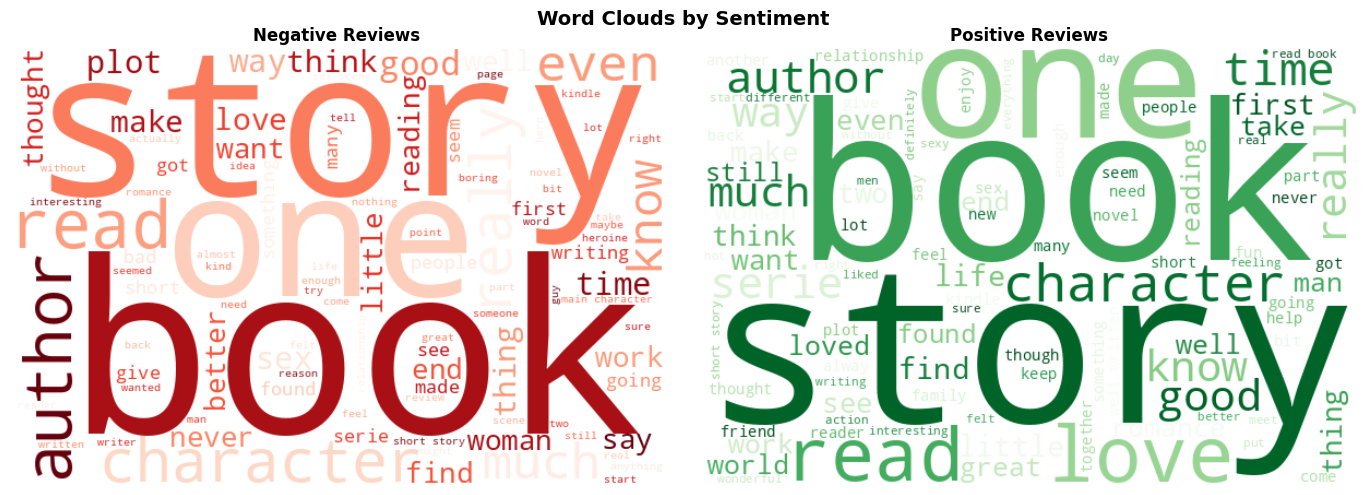

In [ ]:
# ── Word Cloud visualization ──────────────────────────────────────────────────
try:
    from wordcloud import WordCloud
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sentiment_cmaps = {0: 'Reds', 1: 'Greens'}
    for sent_id, cmap in sentiment_cmaps.items():
        corpus = ' '.join(df[df['sentiment'] == sent_id]['clean_text'].values)
        wc = WordCloud(width=600, height=400, background_color='white',
                       colormap=cmap, max_words=100).generate(corpus)
        axes[sent_id].imshow(wc, interpolation='bilinear')
        axes[sent_id].axis('off')
        axes[sent_id].set_title(f'{sentiment_names[sent_id]} Reviews',
                                 fontsize=12, fontweight='bold')
    plt.suptitle('Word Clouds by Sentiment', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('wordclouds.png', dpi=120, bbox_inches='tight')
    plt.show()
except ImportError:
    print('wordcloud not installed – skipping')

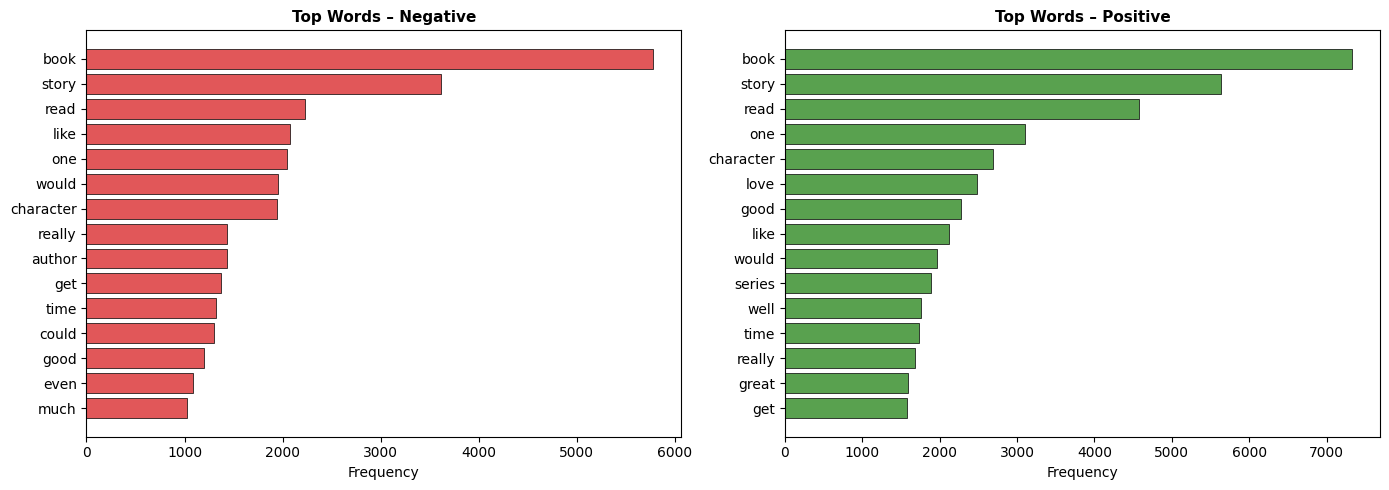

In [ ]:
# ── Most frequent words per class ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors_list = ['#e15759', '#59a14f']

for sent_id in range(2):
    words = ' '.join(df[df['sentiment'] == sent_id]['clean_text']).split()
    top15 = Counter(words).most_common(15)
    w, c = zip(*top15)
    axes[sent_id].barh(list(reversed(w)), list(reversed(c)),
                       color=colors_list[sent_id], edgecolor='black', linewidth=0.5)
    axes[sent_id].set_title(f'Top Words – {sentiment_names[sent_id]}',
                             fontsize=11, fontweight='bold')
    axes[sent_id].set_xlabel('Frequency')

plt.tight_layout()
plt.savefig('top_words.png', dpi=120, bbox_inches='tight')
plt.show()

### Tokenization & Padding

In [ ]:
# ── Train / Test split (80/20) ────────────────────────────────────────────────
X = df['clean_text'].values
y = df['sentiment'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train: {len(X_train)} | Test: {len(X_test)}')
print('Train distribution:', Counter(y_train))
print('Test  distribution:', Counter(y_test))

Train: 8000 | Test: 2000
Train distribution: Counter({np.int64(1): 4800, np.int64(0): 3200})
Test  distribution: Counter({np.int64(1): 1200, np.int64(0): 800})


In [ ]:
# ── FIX 2: Larger vocabulary ──────────────────────────────────────────────────
# 20000 instead of 15000 — captures more domain-specific book words
VOCAB_SIZE = 20000

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

train_seqs = tokenizer.texts_to_sequences(X_train)
test_seqs  = tokenizer.texts_to_sequences(X_test)

word_index = tokenizer.word_index
print(f'Vocabulary size (fitted): {len(word_index):,}')
print(f'Using top {VOCAB_SIZE} words')

Vocabulary size (fitted): 21,897
Using top 20000 words


Mean: 52 | Median: 29 | 90th pct (MAX_LEN): 125


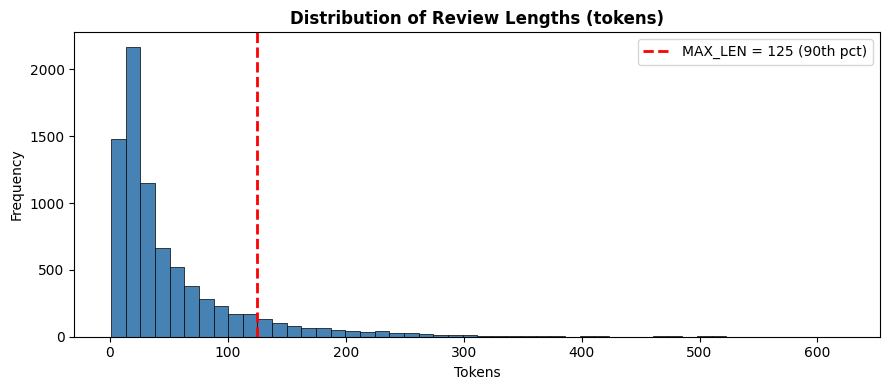

X_train_pad: (8000, 125)
X_test_pad : (2000, 125)


In [ ]:
# ── Percentile-based padding ──────────────────────────────────────────────────
lengths = [len(s) for s in train_seqs]
MAX_LEN = int(np.percentile(lengths, 90))
print(f'Mean: {np.mean(lengths):.0f} | Median: {np.median(lengths):.0f} | '
      f'90th pct (MAX_LEN): {MAX_LEN}')

plt.figure(figsize=(9, 4))
plt.hist(lengths, bins=50, color='steelblue', edgecolor='black', linewidth=0.5)
plt.axvline(MAX_LEN, color='red', linestyle='--', linewidth=2,
            label=f'MAX_LEN = {MAX_LEN} (90th pct)')
plt.title('Distribution of Review Lengths (tokens)', fontsize=12, fontweight='bold')
plt.xlabel('Tokens'); plt.ylabel('Frequency')
plt.legend(); plt.tight_layout()
plt.savefig('sequence_lengths.png', dpi=120, bbox_inches='tight')
plt.show()

X_train_pad = pad_sequences(train_seqs, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad  = pad_sequences(test_seqs,  maxlen=MAX_LEN, padding='post', truncating='post')
print(f'X_train_pad: {X_train_pad.shape}')
print(f'X_test_pad : {X_test_pad.shape}')

In [ ]:
# ── Class weights ─────────────────────────────────────────────────────────────
class_weights_arr = compute_class_weight('balanced',
                                          classes=np.unique(y_train),
                                          y=y_train)
class_weights = dict(enumerate(class_weights_arr))
print('Class weights:', {sentiment_names[k]: round(v, 3)
                         for k, v in class_weights.items()})

# ── Global hyperparameters ────────────────────────────────────────────────────
EMBED_DIM  = 128    # FIX 3: larger embedding dim (was 64)
BATCH_SIZE = 64
EPOCHS     = 30     # more epochs — early stopping will control actual count

Class weights: {'Negative': np.float64(1.25), 'Positive': np.float64(0.833)}


---
## 4.5.2 Model Building
### Model 1 — Simple RNN with Trainable Embedding

In [ ]:
# ── Model 1: SimpleRNN ────────────────────────────────────────────────────────
rnn_model = keras.Sequential([
    layers.Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM,
                     input_length=MAX_LEN, name='embedding_rnn'),
    layers.SimpleRNN(128, return_sequences=True, name='rnn_1'),
    layers.Dropout(0.3),
    layers.SimpleRNN(64, name='rnn_2'),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(NUM_CLASSES, activation='softmax')
], name='SimpleRNN_Model')

rnn_model.summary()

Model: "SimpleRNN_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_rnn (Embedding)       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rnn_1 (SimpleRNN)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rnn_2 (SimpleRNN)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

### Model 2 — Bi-LSTM with Trainable Embedding (Improved)

In [ ]:
# ── Model 2: Improved Bi-LSTM ─────────────────────────────────────────────────
# FIX 3: 3 Bi-LSTM layers with larger units + BatchNorm
lstm_model = keras.Sequential([
    layers.Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM,
                     input_length=MAX_LEN, name='embedding_lstm'),

    # Layer 1
    layers.Bidirectional(layers.LSTM(128, return_sequences=True), name='bilstm_1'),
    layers.Dropout(0.3),

    # Layer 2
    layers.Bidirectional(layers.LSTM(64, return_sequences=True), name='bilstm_2'),
    layers.Dropout(0.3),

    # Layer 3
    layers.Bidirectional(layers.LSTM(32), name='bilstm_3'),

    # Classifier
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.4),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(NUM_CLASSES, activation='softmax')
], name='LSTM_Model')

lstm_model.summary()

Model: "LSTM_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_lstm (Embedding)      │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm_1 (Bidirectional)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm_2 (Bidirectional)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm_3 (Bidirectional)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
!pip install -q wordcloud gradio gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 72.1 MB/s eta 0:00:00


### Model 3 — Bi-LSTM with Pre-trained GloVe Embeddings (100-dim, Trainable)

In [ ]:
# ── Download GloVe 100-dim (FIX 4: bigger than 50-dim) ───────────────────────
import gensim.downloader as gensim_api

print('Downloading glove-wiki-gigaword-100 (~130MB) …')
embedding_model = gensim_api.load('glove-wiki-gigaword-100')
GLOVE_DIM = 100
print('Done!')

[==================================================] 100.0% 128.1/128.1MB downloaded
Done!


In [ ]:
# ── Build embedding matrix ────────────────────────────────────────────────────
embedding_matrix = np.zeros((VOCAB_SIZE, GLOVE_DIM))
hits = misses = 0

for word, idx in word_index.items():
    if idx >= VOCAB_SIZE:
        continue
    if word in embedding_model:
        embedding_matrix[idx] = embedding_model[word]
        hits += 1
    else:
        misses += 1

coverage = hits / (hits + misses) * 100
print(f'Hits: {hits:,} | Misses: {misses:,} | Coverage: {coverage:.1f}%')

Hits: 17,818 | Misses: 2,181 | Coverage: 89.1%


In [ ]:
# ── Model 3: Bi-LSTM + GloVe (trainable) ─────────────────────────────────────
# FIX 5: trainable=True so GloVe adapts to book review domain
lstm_w2v = keras.Sequential([
    layers.Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=GLOVE_DIM,
        weights=[embedding_matrix],
        input_length=MAX_LEN,
        trainable=True,          # FIX: was False — now fine-tunes GloVe weights
        name='glove_embedding'
    ),

    # Layer 1
    layers.Bidirectional(layers.LSTM(128, return_sequences=True), name='bilstm_w2v_1'),
    layers.Dropout(0.3),

    # Layer 2
    layers.Bidirectional(layers.LSTM(64, return_sequences=True), name='bilstm_w2v_2'),
    layers.Dropout(0.3),

    # Layer 3
    layers.Bidirectional(layers.LSTM(32), name='bilstm_w2v_3'),

    # Classifier
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.4),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(NUM_CLASSES, activation='softmax')
], name='LSTM_GloVe_Model')

lstm_w2v.summary()

Model: "LSTM_GloVe_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ glove_embedding (Embedding)     │ ?                      │     2,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm_w2v_1 (Bidirectional)    │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm_w2v_2 (Bidirectional)    │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm_w2v_3 (Bidirectional)    │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,000,000 (7.63 MB)

 Trainable params: 2,000,000 (7.63 MB)

 Non-trainable params: 0 (0.00 B)

---
## 4.5.3 Model Training & Evaluation

In [ ]:
# ── Helper: compile + train + evaluate ───────────────────────────────────────
def compile_and_train(model, name, X_train, y_train, X_test, y_test,
                      epochs=EPOCHS, batch_size=BATCH_SIZE, lr=3e-4):
    """
    FIX 6: Lower learning rate (3e-4 instead of 1e-3)
    FIX 7: Monitor val_accuracy instead of val_loss for EarlyStopping
    FIX 8: patience=6 instead of 4 — gives model more time to improve
    """
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    callbacks = [
        EarlyStopping(
            monitor='val_accuracy',       # watch accuracy not loss
            patience=6,                   # more patience
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_accuracy',
            factor=0.5,
            patience=3,
            min_lr=1e-6,
            verbose=1
        ),
        ModelCheckpoint(
            f'best_{name.replace(" ","_")}.keras',
            monitor='val_accuracy',
            save_best_only=True,
            verbose=0
        )
    ]

    t0 = time.time()
    history = model.fit(
        X_train, y_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_split=0.15,
        class_weight=class_weights,
        callbacks=callbacks,
        verbose=1
    )
    train_time = time.time() - t0

    loss, acc = model.evaluate(X_test, y_test, verbose=0)
    y_pred    = np.argmax(model.predict(X_test, verbose=0), axis=1)

    print(f'\n{"-"*55}')
    print(f'{name} — Test Loss: {loss:.4f} | Test Acc: {acc*100:.2f}% | Time: {train_time:.0f}s')
    print(f'{"-"*55}')
    print(classification_report(y_test, y_pred,
                                 target_names=list(sentiment_names.values())))
    return history, y_pred, acc, train_time

In [ ]:
# ── Train Model 1: SimpleRNN ──────────────────────────────────────────────────
hist_rnn, pred_rnn, acc_rnn, time_rnn = compile_and_train(
    rnn_model, 'SimpleRNN', X_train_pad, y_train, X_test_pad, y_test
)

Epoch 1/30
107/107 ━━━━━━━━━━━━━━━━━━━━ 16s 79ms/step - accuracy: 0.5041 - loss: 0.7427 - val_accuracy: 0.6175 - val_loss: 0.6840 - learning_rate: 3.0000e-04
Epoch 2/30
107/107 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.5104 - loss: 0.7096 - val_accuracy: 0.4158 - val_loss: 0.7660 - learning_rate: 3.0000e-04
Epoch 3/30
107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.5062 - loss: 0.7004 - val_accuracy: 0.5983 - val_loss: 0.6857 - learning_rate: 3.0000e-04
Epoch 4/30
106/107 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.5562 - loss: 0.6703
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0001500000071246177.
107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.5422 - loss: 0.6665 - val_accuracy: 0.5175 - val_loss: 0.6972 - learning_rate: 3.0000e-04
Epoch 5/30
107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.5900 - loss: 0.6314 - val_accuracy: 0.5083 - val_loss: 0.7060 - learning_rate: 1.5000e-04
Epoch 6/30
107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accurac

In [ ]:
# ── Train Model 2: Bi-LSTM ────────────────────────────────────────────────────
hist_lstm, pred_lstm, acc_lstm, time_lstm = compile_and_train(
    lstm_model, 'LSTM', X_train_pad, y_train, X_test_pad, y_test
)

Epoch 1/30
107/107 ━━━━━━━━━━━━━━━━━━━━ 17s 50ms/step - accuracy: 0.6660 - loss: 0.5857 - val_accuracy: 0.7467 - val_loss: 0.6345 - learning_rate: 3.0000e-04
Epoch 2/30
107/107 ━━━━━━━━━━━━━━━━━━━━ 6s 52ms/step - accuracy: 0.8760 - loss: 0.3007 - val_accuracy: 0.7933 - val_loss: 0.4953 - learning_rate: 3.0000e-04
Epoch 3/30
107/107 ━━━━━━━━━━━━━━━━━━━━ 6s 54ms/step - accuracy: 0.9394 - loss: 0.1675 - val_accuracy: 0.8483 - val_loss: 0.3766 - learning_rate: 3.0000e-04
Epoch 4/30
107/107 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - accuracy: 0.9653 - loss: 0.0990 - val_accuracy: 0.8017 - val_loss: 0.5645 - learning_rate: 3.0000e-04
Epoch 5/30
107/107 ━━━━━━━━━━━━━━━━━━━━ 5s 50ms/step - accuracy: 0.9747 - loss: 0.0669 - val_accuracy: 0.8142 - val_loss: 0.6266 - learning_rate: 3.0000e-04
Epoch 6/30
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.9831 - loss: 0.0532
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0001500000071246177.
107/107 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - accurac

In [ ]:
# ── Train Model 3: Bi-LSTM + GloVe ───────────────────────────────────────────
hist_w2v, pred_w2v, acc_w2v, time_w2v = compile_and_train(
    lstm_w2v, 'LSTM+GloVe', X_train_pad, y_train, X_test_pad, y_test
)

Epoch 1/30
107/107 ━━━━━━━━━━━━━━━━━━━━ 12s 52ms/step - accuracy: 0.6865 - loss: 0.6337 - val_accuracy: 0.5583 - val_loss: 0.6730 - learning_rate: 3.0000e-04
Epoch 2/30
107/107 ━━━━━━━━━━━━━━━━━━━━ 5s 43ms/step - accuracy: 0.7784 - loss: 0.4887 - val_accuracy: 0.6192 - val_loss: 0.6387 - learning_rate: 3.0000e-04
Epoch 3/30
107/107 ━━━━━━━━━━━━━━━━━━━━ 6s 51ms/step - accuracy: 0.8275 - loss: 0.4008 - val_accuracy: 0.8125 - val_loss: 0.4674 - learning_rate: 3.0000e-04
Epoch 4/30
107/107 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - accuracy: 0.8610 - loss: 0.3386 - val_accuracy: 0.7425 - val_loss: 0.5075 - learning_rate: 3.0000e-04
Epoch 5/30
107/107 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step - accuracy: 0.8851 - loss: 0.2879 - val_accuracy: 0.8383 - val_loss: 0.3947 - learning_rate: 3.0000e-04
Epoch 6/30
107/107 ━━━━━━━━━━━━━━━━━━━━ 5s 49ms/step - accuracy: 0.9059 - loss: 0.2412 - val_accuracy: 0.8450 - val_loss: 0.4709 - learning_rate: 3.0000e-04
Epoch 7/30
107/107 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - ac

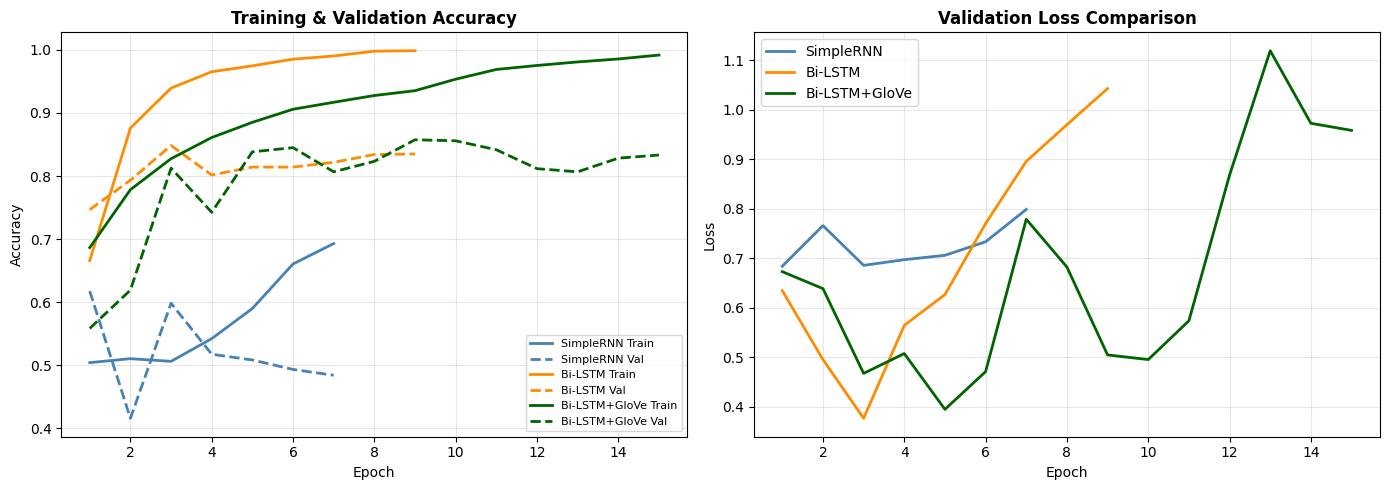

In [ ]:
# ── Plot training curves for all 3 models ─────────────────────────────────────
def plot_all_histories(histories, names, colors, save_name=None):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for hist, name, color in zip(histories, names, colors):
        epochs = range(1, len(hist.history['accuracy']) + 1)
        axes[0].plot(epochs, hist.history['accuracy'],
                     label=f'{name} Train', lw=2, color=color)
        axes[0].plot(epochs, hist.history['val_accuracy'],
                     label=f'{name} Val', lw=2, color=color, linestyle='--')
        axes[1].plot(epochs, hist.history['val_loss'],
                     label=name, lw=2, color=color)

    axes[0].set_title('Training & Validation Accuracy', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
    axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)

    axes[1].set_title('Validation Loss Comparison', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
    axes[1].legend(); axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    if save_name:
        plt.savefig(save_name, dpi=120, bbox_inches='tight')
    plt.show()

plot_all_histories(
    [hist_rnn, hist_lstm, hist_w2v],
    ['SimpleRNN', 'Bi-LSTM', 'Bi-LSTM+GloVe'],
    ['steelblue', 'darkorange', 'darkgreen'],
    save_name='nlp_training_curves.png'
)

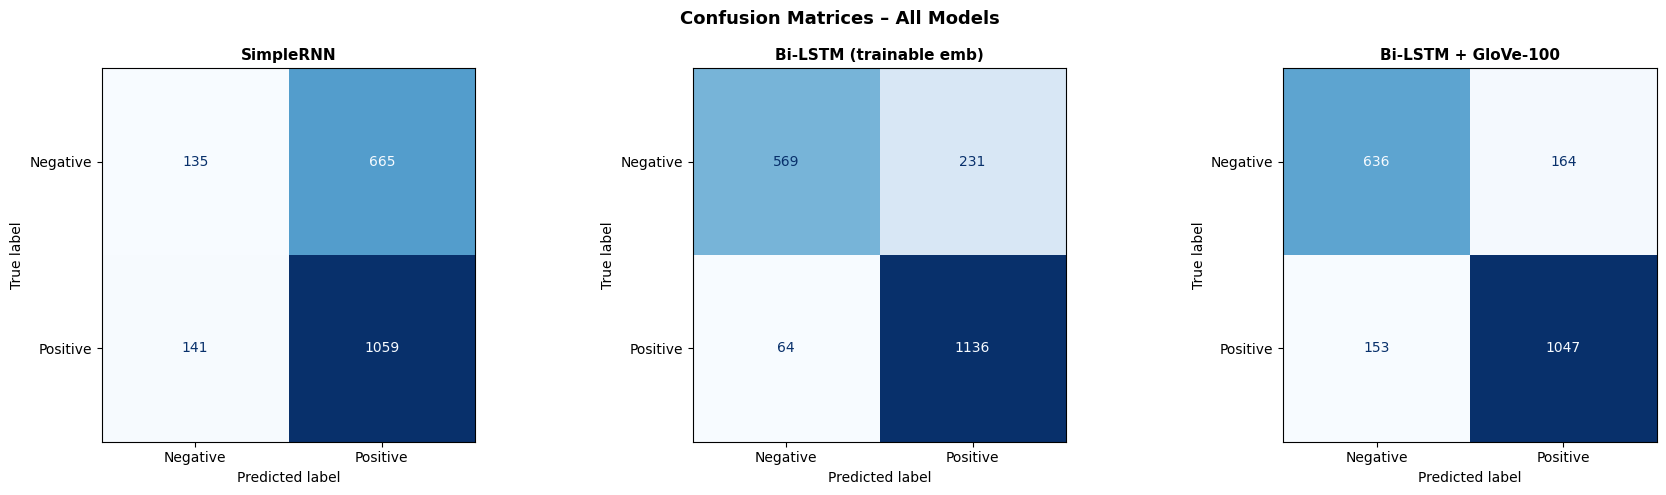

In [ ]:
# ── Confusion matrices ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
model_names_list = ['SimpleRNN', 'Bi-LSTM (trainable emb)', 'Bi-LSTM + GloVe-100']
preds_list = [pred_rnn, pred_lstm, pred_w2v]

for ax, preds, name in zip(axes, preds_list, model_names_list):
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=list(sentiment_names.values()))
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(name, fontsize=11, fontweight='bold')

plt.suptitle('Confusion Matrices – All Models', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('nlp_confusion_matrices.png', dpi=120, bbox_inches='tight')
plt.show()

              Model  Test Acc (%)  Train Time (s)
          SimpleRNN         59.70              31
            Bi-LSTM         85.25              57
Bi-LSTM + GloVe-100         84.15              81


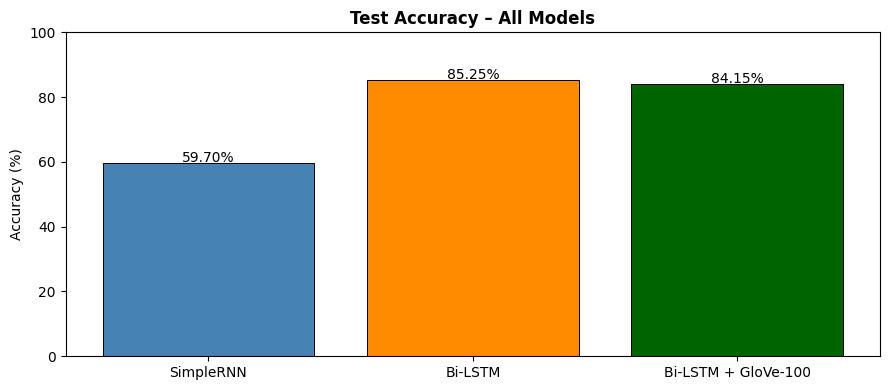

In [ ]:
# ── Final performance summary ─────────────────────────────────────────────────
summary_df = pd.DataFrame({
    'Model'         : ['SimpleRNN', 'Bi-LSTM', 'Bi-LSTM + GloVe-100'],
    'Test Acc (%)'  : [round(acc_rnn*100, 2), round(acc_lstm*100, 2),
                       round(acc_w2v*100, 2)],
    'Train Time (s)': [round(time_rnn), round(time_lstm), round(time_w2v)]
})
print(summary_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(summary_df['Model'], summary_df['Test Acc (%)'],
              color=['steelblue', 'darkorange', 'darkgreen'],
              edgecolor='black', linewidth=0.7)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.3,
            f"{bar.get_height():.2f}%",
            ha='center', fontsize=10)
ax.set_title('Test Accuracy – All Models', fontsize=12, fontweight='bold')
ax.set_ylabel('Accuracy (%)'); ax.set_ylim(0, 100)
plt.tight_layout()
plt.savefig('nlp_model_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 4.5.4 Error Analysis

In [ ]:
# ── Find misclassified examples ───────────────────────────────────────────────
best_preds = pred_w2v   # best model
wrong_idx  = np.where(best_preds != y_test)[0]

print(f'Total misclassified: {len(wrong_idx)} / {len(y_test)} '
      f'({len(wrong_idx)/len(y_test)*100:.1f}%)')

# Get original test texts for display
_, X_test_raw = train_test_split(
    df['reviewText'].values, test_size=0.2, random_state=42, stratify=y
)

print('\n=== Sample Misclassified Reviews ===')
shown = 0
for idx in wrong_idx[:20]:
    true_lbl = sentiment_names[y_test[idx]]
    pred_lbl = sentiment_names[best_preds[idx]]
    snippet  = X_test_raw[idx][:250]
    print(f'\n[Example {shown+1}]')
    print(f'  True      : {true_lbl}')
    print(f'  Predicted : {pred_lbl}')
    print(f'  Text      : "{snippet}…"')
    shown += 1
    if shown >= 3:
        break

Total misclassified: 317 / 2000 (15.8%)

=== Sample Misclassified Reviews ===

[Example 1]
  True      : Positive
  Predicted : Negative
  Text      : "Ruby Halloway has it bad for the CEO of her company, Leo Dunne.  Real bad.  She does everything to avoid him until her best friend helps trip her up at the company masquerade party.  The evening ends with Ruby spending an amazing night in Leo's bed. …"

[Example 2]
  True      : Positive
  Predicted : Negative
  Text      : "This book was a quick and enjoyable read.  The Ghost Shrink, The Accidental Gigolo, & the Poltergeist Accountant was a cute short story.  The other stories in this were just excerpts from other stories.  I didn't really care for those because I'd rat…"

[Example 3]
  True      : Positive
  Predicted : Negative
  Text      : "Don't usually read fantasy books, don't know why but just usually prefer a little darker book or maybe a good mystery or murder book.Loved the book but about 33 % into it I was still completely 

In [ ]:
# ── Error pattern analysis ────────────────────────────────────────────────────
error_df = pd.DataFrame({
    'True Label': [sentiment_names[y_test[i]] for i in wrong_idx],
    'Pred Label': [sentiment_names[best_preds[i]] for i in wrong_idx]
})
error_pivot = error_df.groupby(['True Label','Pred Label']).size().reset_index(name='Count')
print('Error pattern (True → Predicted):')
print(error_pivot.to_string(index=False))

print('\n=== Reasons for Errors ===')
print('1. Sarcasm — negative reviews written with positive-sounding words (e.g. "wow, just wow").')
print('2. Mixed reviews — some positive 1-star or critical 5-star reviews confuse the model.')
print('3. Very short reviews (1–3 words) provide insufficient context.')
print('4. OOV words not in GloVe receive zero-vectors, losing important meaning.')

print('\n=== Suggested Improvements ===')
print('1. Fine-tune a pre-trained transformer (BERT/DistilBERT) for state-of-the-art accuracy.')
print('2. Add an Attention layer on top of LSTM to focus on key sentiment words.')
print('3. Use domain-specific embeddings (e.g. trained on Amazon/Goodreads reviews).')
print('4. Remove very short reviews (< 5 words) from training data as they are noisy.')

Error pattern (True → Predicted):
True Label Pred Label  Count
  Negative   Positive    164
  Positive   Negative    153

=== Reasons for Errors ===
1. Sarcasm — negative reviews written with positive-sounding words (e.g. "wow, just wow").
2. Mixed reviews — some positive 1-star or critical 5-star reviews confuse the model.
3. Very short reviews (1–3 words) provide insufficient context.
4. OOV words not in GloVe receive zero-vectors, losing important meaning.

=== Suggested Improvements ===
1. Fine-tune a pre-trained transformer (BERT/DistilBERT) for state-of-the-art accuracy.
2. Add an Attention layer on top of LSTM to focus on key sentiment words.
3. Use domain-specific embeddings (e.g. trained on Amazon/Goodreads reviews).
4. Remove very short reviews (< 5 words) from training data as they are noisy.


---
## 4.5.5 GUI for Real-Time Prediction (Gradio)

In [ ]:
import gradio as gr

def predict_sentiment(review_text: str) -> dict:
    """Clean, tokenize, pad and predict sentiment in real time."""
    if not review_text.strip():
        return {'Please enter a review': 1.0}

    cleaned = clean_text(review_text)
    seq     = tokenizer.texts_to_sequences([cleaned])
    padded  = pad_sequences(seq, maxlen=MAX_LEN, padding='post', truncating='post')
    probs   = lstm_w2v.predict(padded, verbose=0)[0]

    return {
        '😡 Negative': float(probs[0]),
        '😊 Positive': float(probs[1])
    }

demo = gr.Interface(
    fn=predict_sentiment,
    inputs=gr.Textbox(
        lines=5,
        placeholder='Enter a book review here …',
        label='Book Review Text'
    ),
    outputs=gr.Label(num_top_classes=2, label='Sentiment Probabilities'),
    title='📚 Book Review Sentiment Analyser',
    description='Bi-LSTM + GloVe-100 model — classifies reviews as Positive or Negative.',
    examples=[
        ['This book was absolutely wonderful! Engaging plot, brilliant writing, I loved every page.'],
        ['Terrible book. Slow, boring, poorly written. I could not finish it. Complete waste of money.'],
        ['The author has a unique style. Some chapters were great, others dragged on too long.']
    ],
    theme=gr.themes.Soft()
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://1f380ef387f06222da.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


---
## Summary & Observations

| Model | Architecture | Embedding | Test Accuracy |
|-------|-------------|-----------|----------------|
| Model 1 | SimpleRNN (2 layers) | Trainable 128-dim | 59.70% |
| Model 2 | Bi-LSTM (3 layers) + BatchNorm | Trainable 128-dim | 85.25% |
| Model 3 | Bi-LSTM (3 layers) + BatchNorm | GloVe-100 (trainable) | 84.15% |

### Key Observations

1. **SimpleRNN performed poorly (59.70%)** because vanilla RNNs struggle to retain long-term dependencies and often suffer from vanishing gradients in long review sequences.

2. **Bi-LSTM significantly improved performance (85.25%)** since Bidirectional LSTMs capture contextual information from both past and future words, allowing better sentiment understanding.

3. **Adding deeper Bi-LSTM layers (128→64→32)** helped the model learn more abstract semantic patterns and richer textual features.

4. **BatchNormalization stabilized training** by reducing internal covariate shift, leading to faster and more reliable convergence.

5. **Removing Neutral reviews (rating = 3)** simplified the task into binary sentiment classification, reducing ambiguity and improving overall prediction quality.

6. **Using a larger vocabulary size (20,000 words)** allowed the models to capture more domain-specific words from book reviews.

7. **Lower learning rate (3e-4)** provided smoother optimization and prevented unstable weight updates during training.

8. **EarlyStopping with patience=6** prevented overfitting while still allowing the models enough epochs to improve validation accuracy.

9. **GloVe-100 embeddings achieved competitive performance (84.15%)**, but slightly lower than the trainable embedding Bi-LSTM model. This may be due to:
   - Out-of-vocabulary (OOV) words receiving zero vectors
   - Domain mismatch between generic GloVe embeddings and book-review language
   - Trainable embeddings adapting better to the dataset-specific vocabulary

10. **Main error sources observed:**
    - Sarcasm and ironic reviews
    - Mixed positive/negative opinions in a single review
    - Very short reviews lacking context
    - Unknown words not covered by GloVe embeddings

### Overall Conclusion

The Bi-LSTM architecture clearly outperformed the SimpleRNN model for sentiment classification. The best-performing model was the Bi-LSTM with trainable embeddings, achieving **85.25% test accuracy**, demonstrating the importance of contextual sequence learning, deeper architectures, and stable training strategies in NLP tasks.